# 02. Ko-SBERT 임베딩

전처리 완료된 리뷰 텍스트를 Ko-SBERT 모델로 768차원 벡터로 변환합니다.

| 항목 | 내용 |
|------|------|
| **모델** | `snunlp/KR-SBERT-V40K-klueNLI-augSTS` |
| **출력 차원** | 768 |
| **L2 정규화** | O (normalize_embeddings=True) |
| **batch_size** | 32 |
| **결과 파일** | `df_임베딩2.pkl` (L2 정규화 O) |

Ko-SBERT 채택 이유: 크롤링 데이터는 짧은 후기부터 긴 리뷰까지 길이 편차가 크다. Doc2Vec은 단어 공출현 기반이라 짧은 문서에서 벡터 품질이 떨어지는 반면, Ko-SBERT는 Transformer 기반으로 문장을 통째로 인코딩하여 길이에 무관하게 안정적인 고정 길이 벡터를 출력한다.

## 1. 데이터 로드 및 리뷰 길이 분포 확인

`length` 컬럼 기준 최대값 2건을 제거합니다. 극단적으로 긴 리뷰가 임베딩 품질에 영향을 줄 수 있기 때문입니다.

In [8]:
import pandas as pd

In [2]:
df=pd.read_csv('df_개인최종.csv')
df

,title,content,clean_content,is_ad,length
0,산책중에 개가 개 보고 사납게 짖는거,봉구를 보자마자 사납게 짖던데요 갈색 푸들이....\n봉구는 내가 뭘 이러고 있고 ...,봉구를 보자마자 사납게 짖던데요 갈색 푸들이.... 봉구는 내가 뭘 이러고 있고 그...,False,NaN
1,오늘 산책시키면서 깨달았어요.,행복이는 외동으로만 살아야 하나봐요.\n주말만 유모차 태워서 산책시키는데\n거의 산...,행복이는 외동으로만 살아야 하나봐요. 주말만 유모차 태워서 산책시키는데 거의 산책 ...,False,NaN
2,산책시 아무거나 주워먹어 걱정이에요,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 ㅜ ㅜ 그러다 ...,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 그러다 잘못먹으...,False,NaN
3,서울근교 애견동반펜션 추천해주세요!,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데\n애견동반펜션 좋은곳이랑 근처 동...,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데 애견동반펜션 좋은곳이랑 근처 동반...,False,NaN
4,장마철 산책고민하다 유모차 구입했어요,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라ㅠ\n고민하다가 유...,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라 고민하다가 유모차...,False,NaN
...,...,...,...,...,...
62769,초코펫 하우스 사용하는 강아지 있나용?,강아지 집을 바꿔주려고 하는데\n초코펫 하우스로 바꿔주려고해요!\n- 강아지가 나와...,강아지 집을 바꿔주려고 하는데 초코펫 하우스로 바꿔주려고해요! 강아지가 나와있는 베...,False,120.0
62770,강아지방석이요,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,False,276.0
62771,2개월 강아지가 계속 낑낑 대요.,집에온지 3일정도 됐습니다.\n하루이틀은 얌전히 있다가\n오늘부터 같이 집에 있다가...,집에온지 3일정도 됐습니다. 하루이틀은 얌전히 있다가 오늘부터 같이 집에 있다가 제...,False,137.0
62772,강아지 집위치,"안녕하세요. 비숑(레오)분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요.\n첨에...","안녕하세요. 비숑 레오 분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요. 첨에 ...",False,390.0


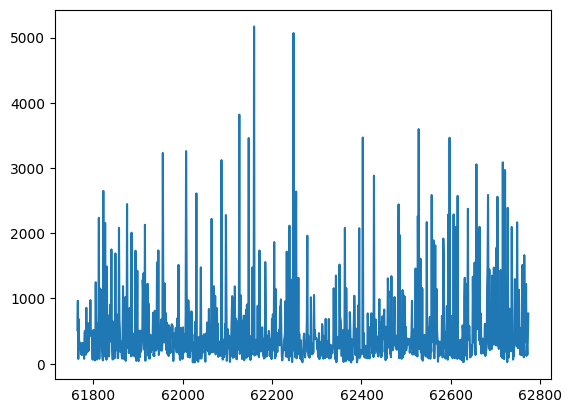

In [6]:
import matplotlib.pyplot as plt

plt.plot(df['length'])

## 2.이상치 제거

In [3]:
# length 최대값 2건 이상치 제거
idx_max = df[df['length'] == df['length'].max()].index  
df = df.drop(idx_max)
idx_max = df[df['length'] == df['length'].max()].index  
df = df.drop(idx_max)

In [5]:
df

,title,content,clean_content,is_ad,length
0,산책중에 개가 개 보고 사납게 짖는거,봉구를 보자마자 사납게 짖던데요 갈색 푸들이....\n봉구는 내가 뭘 이러고 있고 ...,봉구를 보자마자 사납게 짖던데요 갈색 푸들이.... 봉구는 내가 뭘 이러고 있고 그...,False,NaN
1,오늘 산책시키면서 깨달았어요.,행복이는 외동으로만 살아야 하나봐요.\n주말만 유모차 태워서 산책시키는데\n거의 산...,행복이는 외동으로만 살아야 하나봐요. 주말만 유모차 태워서 산책시키는데 거의 산책 ...,False,NaN
2,산책시 아무거나 주워먹어 걱정이에요,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 ㅜ ㅜ 그러다 ...,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 그러다 잘못먹으...,False,NaN
3,서울근교 애견동반펜션 추천해주세요!,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데\n애견동반펜션 좋은곳이랑 근처 동...,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데 애견동반펜션 좋은곳이랑 근처 동반...,False,NaN
4,장마철 산책고민하다 유모차 구입했어요,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라ㅠ\n고민하다가 유...,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라 고민하다가 유모차...,False,NaN
...,...,...,...,...,...
62769,초코펫 하우스 사용하는 강아지 있나용?,강아지 집을 바꿔주려고 하는데\n초코펫 하우스로 바꿔주려고해요!\n- 강아지가 나와...,강아지 집을 바꿔주려고 하는데 초코펫 하우스로 바꿔주려고해요! 강아지가 나와있는 베...,False,120.0
62770,강아지방석이요,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,False,276.0
62771,2개월 강아지가 계속 낑낑 대요.,집에온지 3일정도 됐습니다.\n하루이틀은 얌전히 있다가\n오늘부터 같이 집에 있다가...,집에온지 3일정도 됐습니다. 하루이틀은 얌전히 있다가 오늘부터 같이 집에 있다가 제...,False,137.0
62772,강아지 집위치,"안녕하세요. 비숑(레오)분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요.\n첨에...","안녕하세요. 비숑 레오 분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요. 첨에 ...",False,390.0


## 3. Ko-SBERT 임베딩 (L2 정규화 O)

코사인 기반 분석을 위해 L2 정규화 적용

In [2]:
# 2. 임포트
from sentence_transformers import SentenceTransformer

# 3. Ko-SBERT 모델 로드 (한국어)
model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\rhals\anaconda3\envs\textmining\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rhals\.cache\huggingface\hub\models--snunlp--KR-SBERT-V40K-klueNLI-augSTS. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
# 4. 벡터화
texts = df['clean_content'].tolist()  # 리뷰 컬럼

embeddings = model.encode(
    texts,
    batch_size=32,             
    show_progress_bar=True,     
    normalize_embeddings=True,
    convert_to_numpy=True
)

## 4. 임베딩 결과 저장

768차원 벡터를 vector 컬럼으로 묶어서 pickle로 저장합니다.

In [15]:
emb_df = pd.DataFrame(
    embeddings,
    columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
)
# 원본 df와 합치기 (인덱스 맞추기)
df_use = pd.concat(
    [df.reset_index(drop=True), emb_df.reset_index(drop=True)],
    axis=1
)

In [18]:
df_use

,title,content,clean_content,is_ad,length,dim_0,dim_1,dim_2,dim_3,dim_4,...,dim_758,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767
0,산책중에 개가 개 보고 사납게 짖는거,봉구를 보자마자 사납게 짖던데요 갈색 푸들이....\n봉구는 내가 뭘 이러고 있고 ...,봉구를 보자마자 사납게 짖던데요 갈색 푸들이.... 봉구는 내가 뭘 이러고 있고 그...,False,NaN,-0.049229,0.033518,-0.003451,0.008580,0.029797,...,-0.007827,-0.021568,0.001347,-0.022511,-0.045894,-0.004889,0.072398,-0.011074,-0.012476,0.034640
1,오늘 산책시키면서 깨달았어요.,행복이는 외동으로만 살아야 하나봐요.\n주말만 유모차 태워서 산책시키는데\n거의 산...,행복이는 외동으로만 살아야 하나봐요. 주말만 유모차 태워서 산책시키는데 거의 산책 ...,False,NaN,-0.027225,0.040590,-0.006163,-0.048904,0.018711,...,-0.046403,-0.032355,-0.001096,-0.035249,-0.006505,-0.005431,0.023513,-0.053224,0.020414,0.027918
2,산책시 아무거나 주워먹어 걱정이에요,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 ㅜ ㅜ 그러다 ...,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 그러다 잘못먹으...,False,NaN,0.028064,-0.006754,-0.034082,-0.017744,-0.008898,...,-0.067695,-0.009117,0.010117,-0.013793,-0.009461,0.049245,0.096196,0.043027,-0.023614,-0.017264
3,서울근교 애견동반펜션 추천해주세요!,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데\n애견동반펜션 좋은곳이랑 근처 동...,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데 애견동반펜션 좋은곳이랑 근처 동반...,False,NaN,-0.020872,-0.013023,-0.019658,-0.079618,0.028150,...,-0.052730,-0.047306,-0.039335,-0.016954,0.012246,-0.024863,-0.005940,0.005240,0.010521,-0.032069
4,장마철 산책고민하다 유모차 구입했어요,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라ㅠ\n고민하다가 유...,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라 고민하다가 유모차...,False,NaN,-0.013376,-0.036473,-0.074228,-0.051417,0.025336,...,-0.026877,-0.020389,0.022255,-0.008374,-0.017900,0.000298,-0.002792,-0.015256,0.023435,0.002937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62767,초코펫 하우스 사용하는 강아지 있나용?,강아지 집을 바꿔주려고 하는데\n초코펫 하우스로 바꿔주려고해요!\n- 강아지가 나와...,강아지 집을 바꿔주려고 하는데 초코펫 하우스로 바꿔주려고해요! 강아지가 나와있는 베...,False,120.0,-0.018168,-0.011418,-0.006795,-0.038823,-0.002208,...,0.009011,0.008960,-0.009461,0.034318,-0.016603,-0.024615,0.049641,0.024690,-0.051029,-0.020923
62768,강아지방석이요,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,False,276.0,-0.000933,0.001498,-0.008416,-0.028298,0.023069,...,-0.017607,0.013771,0.000869,0.006267,-0.016672,0.005592,0.056617,0.008053,-0.011275,-0.006159
62769,2개월 강아지가 계속 낑낑 대요.,집에온지 3일정도 됐습니다.\n하루이틀은 얌전히 있다가\n오늘부터 같이 집에 있다가...,집에온지 3일정도 됐습니다. 하루이틀은 얌전히 있다가 오늘부터 같이 집에 있다가 제...,False,137.0,0.001979,-0.026233,-0.005964,-0.039671,-0.017267,...,-0.035405,0.032403,0.049873,-0.009483,-0.064800,0.011752,0.017233,-0.032562,-0.115691,-0.030660
62770,강아지 집위치,"안녕하세요. 비숑(레오)분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요.\n첨에...","안녕하세요. 비숑 레오 분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요. 첨에 ...",False,390.0,-0.013585,-0.013384,-0.023086,-0.017447,0.002632,...,-0.042479,0.007260,-0.007086,0.063349,-0.014689,-0.034006,0.096094,-0.014749,-0.054971,-0.029134


In [ ]:
df_use['vector'] = list(embeddings)

In [23]:
import pickle

# 저장
df_use.to_pickle('df_임베딩2.pkl')

In [4]:
import pandas as pd
df=pd.read_csv('df_개인최종.csv')
df

,title,content,clean_content,is_ad,length
0,산책중에 개가 개 보고 사납게 짖는거,봉구를 보자마자 사납게 짖던데요 갈색 푸들이....\n봉구는 내가 뭘 이러고 있고 ...,봉구를 보자마자 사납게 짖던데요 갈색 푸들이.... 봉구는 내가 뭘 이러고 있고 그...,False,NaN
1,오늘 산책시키면서 깨달았어요.,행복이는 외동으로만 살아야 하나봐요.\n주말만 유모차 태워서 산책시키는데\n거의 산...,행복이는 외동으로만 살아야 하나봐요. 주말만 유모차 태워서 산책시키는데 거의 산책 ...,False,NaN
2,산책시 아무거나 주워먹어 걱정이에요,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 ㅜ ㅜ 그러다 ...,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 그러다 잘못먹으...,False,NaN
3,서울근교 애견동반펜션 추천해주세요!,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데\n애견동반펜션 좋은곳이랑 근처 동...,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데 애견동반펜션 좋은곳이랑 근처 동반...,False,NaN
4,장마철 산책고민하다 유모차 구입했어요,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라ㅠ\n고민하다가 유...,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라 고민하다가 유모차...,False,NaN
...,...,...,...,...,...
62769,초코펫 하우스 사용하는 강아지 있나용?,강아지 집을 바꿔주려고 하는데\n초코펫 하우스로 바꿔주려고해요!\n- 강아지가 나와...,강아지 집을 바꿔주려고 하는데 초코펫 하우스로 바꿔주려고해요! 강아지가 나와있는 베...,False,120.0
62770,강아지방석이요,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,False,276.0
62771,2개월 강아지가 계속 낑낑 대요.,집에온지 3일정도 됐습니다.\n하루이틀은 얌전히 있다가\n오늘부터 같이 집에 있다가...,집에온지 3일정도 됐습니다. 하루이틀은 얌전히 있다가 오늘부터 같이 집에 있다가 제...,False,137.0
62772,강아지 집위치,"안녕하세요. 비숑(레오)분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요.\n첨에...","안녕하세요. 비숑 레오 분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요. 첨에 ...",False,390.0


In [5]:
idx_max = df[df['length'] == df['length'].max()].index  
df = df.drop(idx_max)
idx_max = df[df['length'] == df['length'].max()].index  
df = df.drop(idx_max)

In [6]:
df

,title,content,clean_content,is_ad,length
0,산책중에 개가 개 보고 사납게 짖는거,봉구를 보자마자 사납게 짖던데요 갈색 푸들이....\n봉구는 내가 뭘 이러고 있고 ...,봉구를 보자마자 사납게 짖던데요 갈색 푸들이.... 봉구는 내가 뭘 이러고 있고 그...,False,NaN
1,오늘 산책시키면서 깨달았어요.,행복이는 외동으로만 살아야 하나봐요.\n주말만 유모차 태워서 산책시키는데\n거의 산...,행복이는 외동으로만 살아야 하나봐요. 주말만 유모차 태워서 산책시키는데 거의 산책 ...,False,NaN
2,산책시 아무거나 주워먹어 걱정이에요,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 ㅜ ㅜ 그러다 ...,산책시 땅에 떨어져있는 음식이나 풀 흙등 뭐든 누워먹어서 걱정이에요 그러다 잘못먹으...,False,NaN
3,서울근교 애견동반펜션 추천해주세요!,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데\n애견동반펜션 좋은곳이랑 근처 동...,7월 중순에 강아지랑 같이 가족여행 갈려고 하는데 애견동반펜션 좋은곳이랑 근처 동반...,False,NaN
4,장마철 산책고민하다 유모차 구입했어요,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라ㅠ\n고민하다가 유...,저희집 강아지가 물을 엄청 무서워하는데 산책은 꼭 해야하는 아이라 고민하다가 유모차...,False,NaN
...,...,...,...,...,...
62769,초코펫 하우스 사용하는 강아지 있나용?,강아지 집을 바꿔주려고 하는데\n초코펫 하우스로 바꿔주려고해요!\n- 강아지가 나와...,강아지 집을 바꿔주려고 하는데 초코펫 하우스로 바꿔주려고해요! 강아지가 나와있는 베...,False,120.0
62770,강아지방석이요,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,거실에 강아지 집 대신 애들자리로 방석 이나 쿠션 깔아주시는분 보통 얼마정도에 갈아...,False,276.0
62771,2개월 강아지가 계속 낑낑 대요.,집에온지 3일정도 됐습니다.\n하루이틀은 얌전히 있다가\n오늘부터 같이 집에 있다가...,집에온지 3일정도 됐습니다. 하루이틀은 얌전히 있다가 오늘부터 같이 집에 있다가 제...,False,137.0
62772,강아지 집위치,"안녕하세요. 비숑(레오)분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요.\n첨에...","안녕하세요. 비숑 레오 분양받은지 2달쯤 되어가는데요, 레오는 4개월이에요. 첨에 ...",False,390.0


In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")

In [7]:
# 임베딩
texts = df['clean_content'].tolist() 
embeddings = model.encode(
    texts,
    batch_size=32,             
    show_progress_bar=True,     
    convert_to_numpy=True
)

emb_df = pd.DataFrame(
    embeddings,
    columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
)
df_use = pd.concat(
    [df.reset_index(drop=True), emb_df.reset_index(drop=True)],
    axis=1
)

df_use.to_pickle('df_임베딩3.pkl')

Batches:   0%|          | 0/1962 [00:00<?, ?it/s]

In [9]:
import pandas as pd

df=pd.read_pickle('df_임베딩3.pkl')

In [10]:
import re

# dim_* 컬럼명 모으기
dim_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"dim_\d+", c)],
    key=lambda x: int(x.split("_")[1])
)

# 리스트형으로 vector 컬럼 생성
df['vector'] = df[dim_cols].values.tolist()